In [91]:
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn

import gymnasium as gym


plt.rcParams["figure.figsize"] = (10, 5)

In [92]:
class PolicyNetwork(nn.Module):

    def __init__(self, obs_space_dims: int, action_space_dims: int):
        super().__init__()

        hidden_space1 = 16
        hidden_space2 = 32

        self.policy_net = nn.Sequential(
            nn.Flatten(start_dim=0),
            nn.Linear(obs_space_dims, hidden_space1),
            nn.ReLU(),
            nn.Linear(hidden_space1, hidden_space2),
            nn.ReLU(),
            nn.Linear(hidden_space2, action_space_dims),
        )

    def forward(self, x: torch.Tensor, mask: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        logits = self.policy_net(x.float())
        logits[~mask] = torch.finfo().min

        return logits

In [101]:
class Reinforce:
    def __init__(self, obs_space_dims: int, action_space_dims: int):
        self.lr = 1e-4
        self.gamma = 0.99
        self.eps = 1e-6

        self.log_probs = []
        self.rewards = []

        self.net = PolicyNetwork(obs_space_dims, action_space_dims)
        self.optim = torch.optim.AdamW(self.net.parameters(), lr=self.lr)

    def sample_action(self, state: np.ndarray, mask: np.ndarray) -> float:
        state = torch.tensor(np.array(state))
        mask = torch.tensor(np.array(mask), dtype=bool)
        logits = self.net(state, mask)

        distrib = torch.distributions.categorical.Categorical(logits=logits)
        action = distrib.sample(sample_shape=torch.Size([1]))
        log_prob = distrib.log_prob(action)

        action = action.item()

        self.log_probs.append(log_prob)

        return int(action)

    def update(self):
        running_g = 0
        gs = []

        for r in self.rewards[::-1]:
            running_g = r + self.gamma * running_g
            gs.insert(0, running_g)
        
        deltas = torch.tensor(gs)

        loss = 0
        for log_prob, delta in zip(self.log_probs, deltas):
            loss += log_prob * delta * -1.0

        self.optim.zero_grad()
        loss.backward()
        self.optim.step()

        self.log_probs = []
        self.rewards = []

In [103]:
from fanorona_aec import fanorona_v1

env = fanorona_v1.env()

total_num_episodes = int(1000)
seeds = (1,) # (1, 2, 3, 5, 8)

obs_space_dims = np.prod(env.observation_space('player_0')['observation'].shape)
action_space_dims = env.action_space('player_0').n
rewards_over_seeds = []

In [104]:
for seed in seeds:
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

    agent = Reinforce(obs_space_dims, action_space_dims)
    rewards_over_episodes = []

    for episode in range(total_num_episodes):
        env.reset(seed=seed)
        obs, info = env.observations['player_0'], env.infos['player_0']
        done = False
        rewards_in_episode = []

        while not done:
            env.render()
            curr_agent = env.agent_selection
            action = agent.sample_action(obs['observation'], obs['action_mask'])
            print(action)
            env.step(action)
            obs = env.observations[curr_agent]
            reward = env.rewards[curr_agent]
            terminated = env.terminations[curr_agent]
            truncated = env.truncations[curr_agent]
            info = env.infos[curr_agent]
            agent.rewards.append(reward)
            rewards_in_episode.append(reward)

            done = terminated or truncated

        rewards_over_episodes.append(rewards_in_episode[-1])
        agent.update()

        if episode % 10 == 0:
            avg_reward = int(np.mean(rewards_in_episode))
            print(f"Episode: {episode} Average Reward: {avg_reward}")

352
518
[WARNING]: Illegal move made, game terminating with current player losing. 
obs['action_mask'] contains a mask of all legal moves that can be chosen.
Episode: 0 Average Reward: 0
352
518
[WARNING]: Illegal move made, game terminating with current player losing. 
obs['action_mask'] contains a mask of all legal moves that can be chosen.
352
331
[WARNING]: Illegal move made, game terminating with current player losing. 
obs['action_mask'] contains a mask of all legal moves that can be chosen.
518
352
[WARNING]: Illegal move made, game terminating with current player losing. 
obs['action_mask'] contains a mask of all legal moves that can be chosen.
517
517
[WARNING]: Illegal move made, game terminating with current player losing. 
obs['action_mask'] contains a mask of all legal moves that can be chosen.
517
352
[WARNING]: Illegal move made, game terminating with current player losing. 
obs['action_mask'] contains a mask of all legal moves that can be chosen.
517
518
[WARNING]: Ille

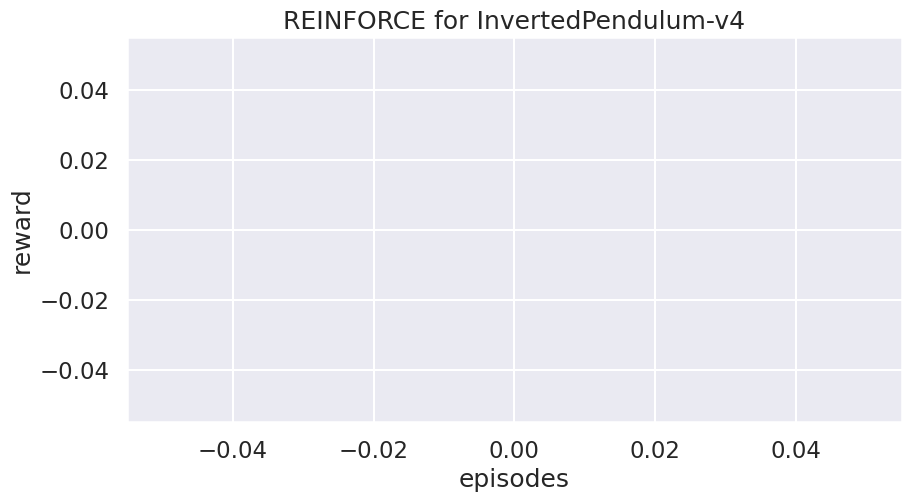

In [105]:
rewards_to_plot = [[reward[0] for reward in rewards] for rewards in rewards_over_seeds]
df1 = pd.DataFrame(rewards_to_plot).melt()
df1.rename(columns={"variable": "episodes", "value": "reward"}, inplace=True)
sns.set(style="darkgrid", context="talk", palette="rainbow")
sns.lineplot(x="episodes", y="reward", data=df1).set(
    title="REINFORCE for Fanorona v1"
)
plt.show()